### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

Report by:

- Quyi Le -- `Quyi.Le@etu.univ-grenoble-alpes.fr`
- Olesia Zaichenko -- `olesia.zaichenko@etu.univ-grenoble-alpes.fr`
- Matvei Kudashev -- `matvei.kudashev@etu.univ-grenoble-alpes.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2026-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.


C:\Users\mak20\AppData\Local\Temp\ipykernel_73752\767131013.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


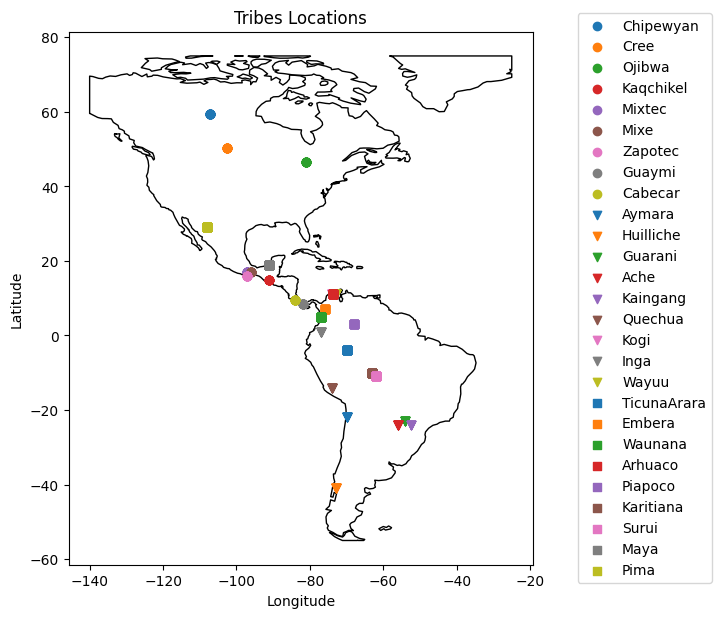

In [14]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

In this code we read dataset and create GeoDataFrame with two geometry columns (longitude, latitude), which will be our target.

1. **Data Loading and Preliminary Localization**   
The code first uses pandas to load the `NAm2.txt file`. Since this dataset contains 5709 genetic markers as predictors while our goal is to predict geographic coordinates, the code extracts columns 7 and 8 (`latitude` and `longitude`) and column 3 (tribe name `Pop`) via index.

2. **Spatial Geometrization**  
To accurately annotate the map, the code utilizes `gpd.points_from_xy` to transform numerical latitude and longitude into geospatial Point objects.

3. **Map Clipping and Visual Focusing**  
The code loads the `naturalearth.land` world map data and executes the `world.clip([-140, -55, -25, 75])` operation.
Since our research focuses on Indian tribes from South, Central, and North America, a full-world display would be distracting. By clipping the coordinates, we lock the field of view to a rectangular area between 140°W to 55°W and 25°S to 75°N.

4. **Iteration Logic**  
For every person we know their tribe, and we want to mark people from the same tribe on the map in the same way. As every pepson from the same tribe has the same longitude and latitude we get only one point on map for each tribe. So, it toggles colors using `i % 9` and switches marker shapes (e.g., circles, inverted triangles, squares) using `i // 9`.


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [2]:
import numpy as np

X = df[df.columns[8:]].values
y_lat = df['lat']
y_lon = df['long']

#beta_hat_lat = np.linalg.solve(X.T @ X, X.T @ y_lat)

numpy.linalg.solve runs errors LinAlgError: Singular matrix. Matrix  $X^\top X$ is singular as rank(X) $\leq N=494 $. The system $X^\top X \hat{\beta} = X^\top y$ has infinitely many solutions, and solver can't handle them

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [3]:
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X, y_lat, rcond=None)
print(f"Matrix X rank: {rank}")
print(f"Number of predictors p: {X.shape[1]}")
print(f"First 5 coefficients (lstsq): {beta_lstsq[:5]}")

Matrix X rank: 494
Number of predictors p: 5709
First 5 coefficients (lstsq): [ 0.04545534  0.01192706 -0.01172507 -0.0140091   0.03215393]


`linalg.solve` requires the system to have exactly one solution. In our case, the number of observations is smaller than the number of features. Therefore, there are infinitely many sets of $\hat{\beta}$ coefficients that explain the data equally well. Because of this, solve fails with an error.
`linalg.lstsq` does not require a unique solution. It searches for the solution with the  $min||y-X\beta||_2$, that is, the $\hat{\beta}$ coefficients in the sum of squares are as small as possible. Therefore, we can choose one solution from an infinite set

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [4]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors] #.values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
print(lr.coef_)

[-0.0915134  -0.01377165  0.10040245 ...  0.04729317 -0.08965224
  0.01931056]


The reason of this difference is that by default, `LinearRegression()` performs **re-centering** on the predictors, subtracting the means $\bar{x}$ and $\bar{y}$. After re-centering, the intercept of the model equals $\bar{y}$ of the training dataset.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

- Geometric Interpretation: PCA identifies the directions of "maximum spread" within the multidimensional space. The first principal component is the line that maximizes the variance of the projected points. Subsequent PCs find directions that maximize remaining variance while being orthogonal to previous ones.
- Statistical Interpretation: PCA finds linear combinations of the original variables that are uncorrelated with each other and ordered by decreasing explained variance, which allows for data dimensionality reduction with minimal information loss.
The principal components are the eigenvectors of the covariance matrix $\Sigma = \frac{1}{N} X^\top X$, and the corresponding eigenvalues ​​are the variance they explain.


**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

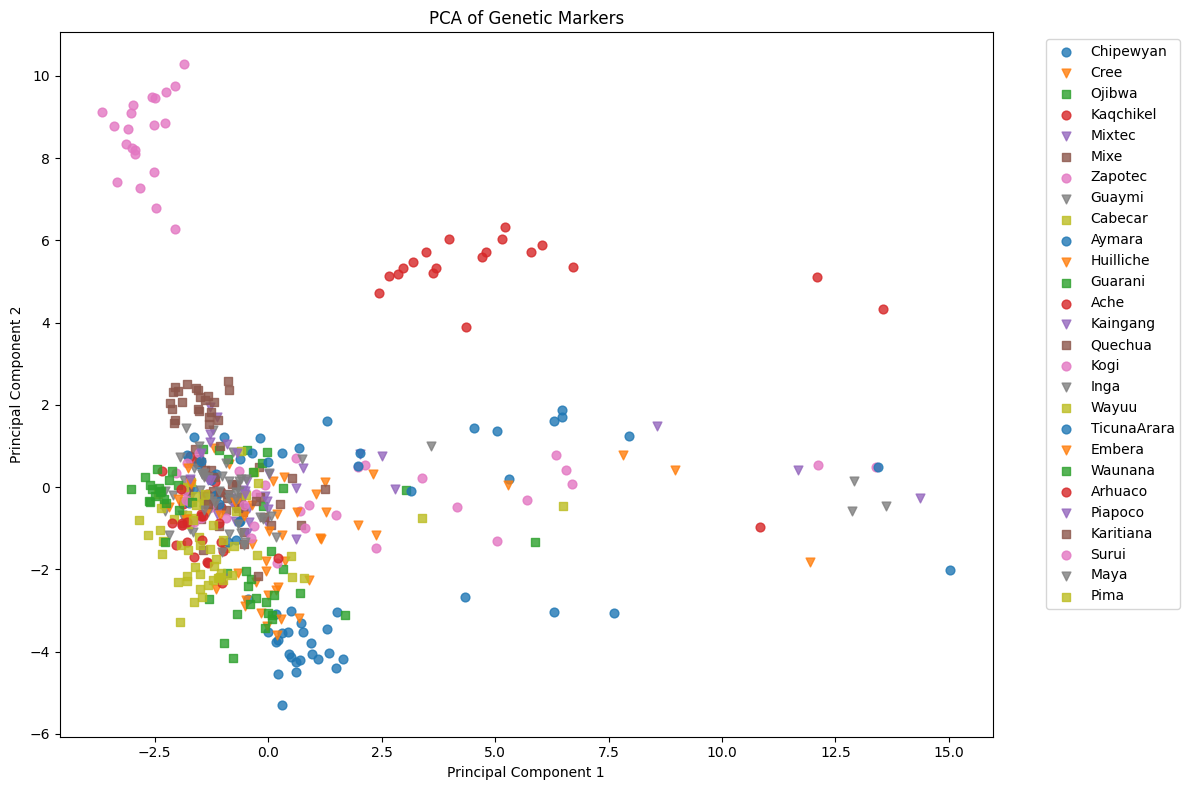

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# plot the PCA results
plt.figure(figsize=(12, 8))
marker_list = ['o', 'v', 's'] 
colors_list = [f'C{i}' for i in range(9)] 

for i, tribe in enumerate(gdf['Pop'].unique()):
    mask = (gdf['Pop'] == tribe).to_numpy()
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=marker_list[i % len(marker_list)],
        color=colors_list[i % len(colors_list)],
        label=tribe,
        alpha=0.8,
        s=40,
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Genetic Markers')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



The graph shows that most of the tribes are mixed together in a single dense cloud, and there are no clear clusters. Only a few groups stand out, indicating that the first two PCs explain only a small portion of the variance and separating the tribes more clearly requires significantly more components.

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:

Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?\

We will plot **(b)** and **(c)** together for better comparison.

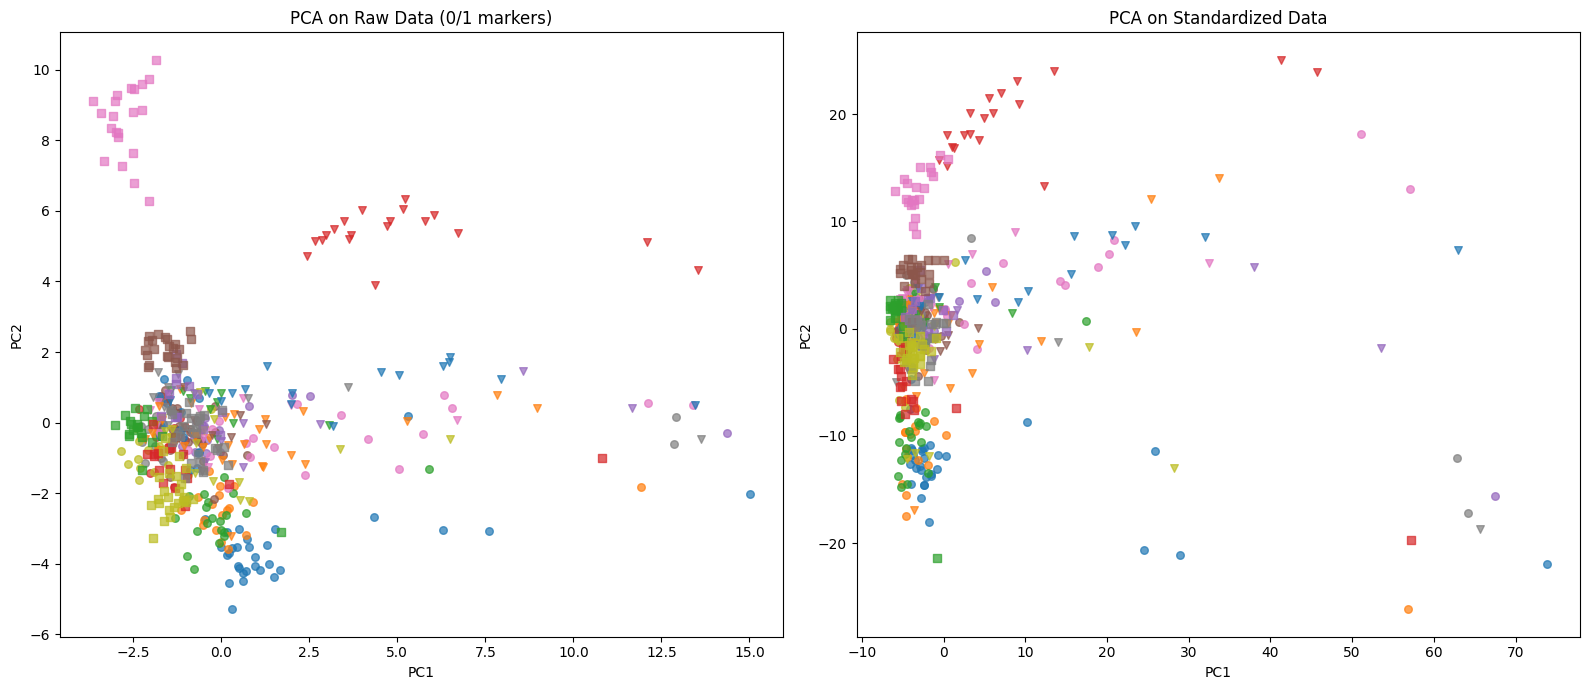

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_std)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
unique_tribes = df['Pop'].unique()
marker_list = ['o', 'v', 's'] 
colors_list = [f'C{i}' for i in range(9)] 

for i, tribe in enumerate(unique_tribes):
    mask = (df['Pop'] == tribe)
    style = {'marker': marker_list[(i // 10) % len(marker_list)], 
             'color': colors_list[i % len(colors_list)], 's': 30, 'alpha': 0.7}
    
    ax1.scatter(X_pca_raw[mask, 0], X_pca_raw[mask, 1], **style)
    ax2.scatter(X_pca_std[mask, 0], X_pca_std[mask, 1], **style)

ax1.set_title("PCA on Raw Data (0/1 markers)")
ax2.set_title("PCA on Standardized Data")
for ax in [ax1, ax2]:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

We find that the right plot (Standardized) undergoes significant `stretching` and `weight redistribution` compared to the left plot (Raw).

We guess the reason is the difference in rare gene.   
- In Raw Data: A rare gene with frequency $p=0.01$ has a variance of only $0.01 \times 0.99 \approx 0.01$. It holds almost no "voting power" in PCA.  
- After Standardization: Features are transformed as $z = \frac{x - p}{\sqrt{p(1-p)}}$. For a rare gene (individual with $x=1$), the standardized value becomes $\frac{1 - 0.01}{\sqrt{0.01 \times 0.99}} \approx 9.9$. But for a common gene ($p=0.5, x=1$), the standardized value is only $\frac{1 - 0.5}{\sqrt{0.5 \times 0.5}} = 1$.  
Standardization grants "rare mutations" extremely high weights (amplified by 10x or more). 

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

So we think each method can solve specific situations.

- If the goal is to observe major ancestral migration structures, the left plot might be more representative as it reflects common variants shared by the majority.

- If the goal is to capture fine-grained familial or small-tribe traits, the right plot is more effective as it uncovers hidden rare signals.

We want to try to solve the first problem, so we will not use normalization for the rest of the TP.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

First two pcs' variance: 3.57%


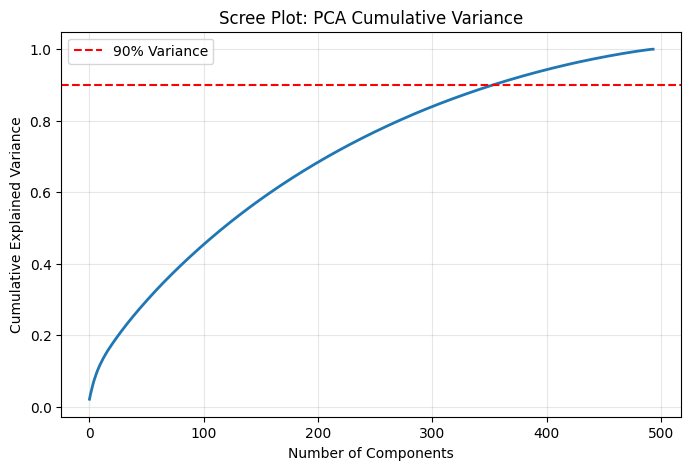

In [7]:
pca_full = PCA().fit(X)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

print(f"First two pcs' variance: {cum_variance[1]*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(cum_variance, linewidth=2)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: PCA Cumulative Variance')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

We find that it is only $3.57\%$ if we use the first two PCs. The graph shows that the growth of each subsequent component decreases gradually, there is no quick growth and no exit to a plateau

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

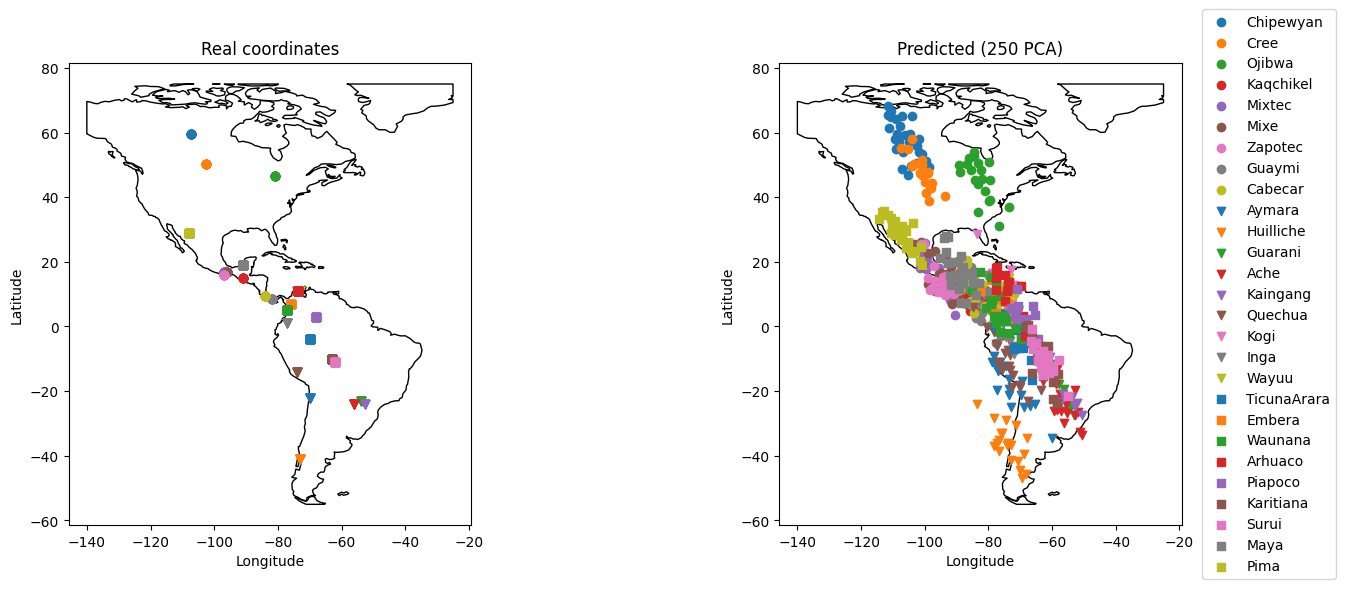

In [8]:
pca_250 = PCA(n_components=250)
X_pca_250 = pca_250.fit_transform(X)

y_both = df[['lat', 'long']].values
lr_pcr = LinearRegression()
lr_pcr.fit(X_pca_250, y_both)
y_pred = lr_pcr.predict(X_pca_250)

gdf_pred = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(y_pred[:, 1], y_pred[:, 0]))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, gdf_plot, title in zip(axes, [gdf, gdf_pred], ['Real coordinates', 'Predicted (250 PCA)']):
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    for i, tribe in enumerate(df['Pop'].unique()):
        mask = df['Pop'] == tribe
        ax.scatter(gdf_plot[mask].geometry.x, gdf_plot[mask].geometry.y,
                   marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
axes[1].legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.tight_layout()
plt.show()

But this result is generally too optimistic. We are predicting and plotting on the training dataset. Since we used as many as 250 features (PCs) to fit only 494 samples, the model is highly susceptible to overfitting. It likely captured not only the genuine genetic-geographic correlations but also the noise specific to the training samples.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [9]:
from sklearn.metrics.pairwise import haversine_distances

def haversine_error_km(y_true, y_pred):
    R = 6371
    real_rad = np.radians(y_true)
    pred_rad = np.radians(y_pred)
    dists = np.diag(haversine_distances(real_rad, pred_rad))
    return np.mean(dists) * R

error_km = haversine_error_km(y_both, y_pred)
print(f"Mean training error: {error_km:.2f} km")

Mean training error: 633.72 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

- Cross-validation is a method for more “fairly” assessing a model’s error and its generalization ability. Instead of a single random split into training and test sets, CV divides the data into training and test sets multiple times; in each iteration, the model is trained on the training set, tested on the test set, and the resulting errors are then averaged. This approach reduces the dependence of the result on a specific split, allows for more efficient use of data, and provides a more reliable assessment of the model’s quality.

- For non-IID data, a standard random split cannot be used because it can lead to data leakage (dependent data will end up in both the training and test sets) and an overly optimistic assessment of quality. In this case, the split must account for the structure of the dependency between observations. For example, with group-wise dependencies, `GroupKFold` is used so that each group falls entirely into either the train or test set. For time-series data, `TimeSeriesSplit` or a sliding-window scheme is used so that the model is trained on the past and tested on the future.


**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

The first approach involves using a simple K-fold cross-validation, in which we randomly split the entire training dataset into training and test sets. However, in our case, this could lead to information leakage, since members of the same tribe are very similar both genetically and geographically. Thus, if the training dataset contains people from tribe A, our model will accurately predict their geographic location, and when the model encounters a person from the same tribe, it will also accurately predict their location, since these people will be genetically nearly identical.

In our task, we want to predict a person’s residential coordinates based on certain characteristics, and we have several tribes. A person’s coordinates depend on which tribe they belong to. 
Therefore, to determine the final model, we will use `GroupKFold` to ensure that the training data does not end up in the test data. Otherwise, we will have a data leak, and we will incorrectly assess the model’s predictive quality.

We will test `KFold` and `GroupKFold` and then compare the estimates on the test set and the results on the graph. They will show that our assumption about data leakage and the need to account for groups is correct


**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, GroupKFold

# part with KFold
cv = KFold(n_splits=10, shuffle=True, random_state=42)
X_vals = df[df.columns[8:]].values

pipeline = make_pipeline(PCA(n_components=4), LinearRegression())

train_errors, test_errors = [], []
for train_idx, test_idx in cv.split(X_vals):
    X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
    y_tr, y_te = y_both[train_idx], y_both[test_idx]
    pipeline.fit(X_tr, y_tr)
    train_errors.append(haversine_error_km(y_tr, pipeline.predict(X_tr)))
    test_errors.append(haversine_error_km(y_te, pipeline.predict(X_te)))

print(f"Mean training error for KFold: {np.mean(train_errors):.2f} km")
print(f"Mean test error for KFold:     {np.mean(test_errors):.2f} km")

# part with GroupKFold

groups = df['Pop'].values
cv_group = GroupKFold(n_splits=10)
train_errors_group, test_errors_group = [], []
for train_idx, test_idx in cv_group.split(X_vals, y_both, groups):
    X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
    y_tr, y_te = y_both[train_idx], y_both[test_idx]
    pipeline.fit(X_tr, y_tr)
    train_errors_group.append(haversine_error_km(y_tr, pipeline.predict(X_tr)))
    test_errors_group.append(haversine_error_km(y_te, pipeline.predict(X_te)))

print(f"Mean training error for GroupKFold: {np.mean(train_errors_group):.2f} km")
print(f"Mean test error for GroupKFold:     {np.mean(test_errors_group):.2f} km")

Mean training error for KFold: 1808.09 km
Mean test error for KFold:     1878.25 km
Mean training error for GroupKFold: 1799.93 km
Mean test error for GroupKFold:     2429.64 km


With KFold, the test error is 1878 km, while with GroupKFold it is 2430 km. The gap between these values confirms that KFold is overly optimistic: members of the same tribe end up in both train and test sets, so the model "recognizes" genetically similar individuals rather than truly generalizing. GroupKFold provides a more realistic estimate of prediction quality for unseen tribes.

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

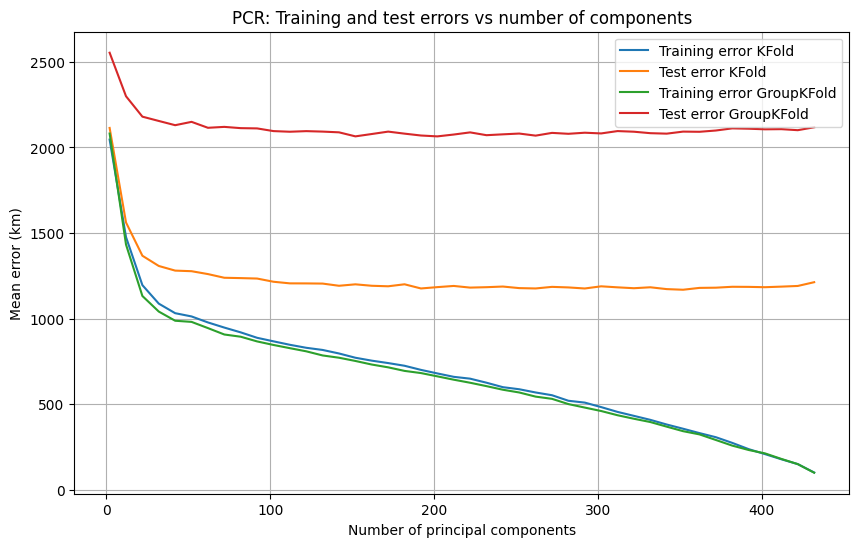

In [11]:
n_components_list = list(range(2, 441, 10))

# part with KFold
mean_train_errors, mean_test_errors = [], []

for n in n_components_list:
    pipe = make_pipeline(PCA(n_components=n), LinearRegression())
    tr_err, te_err = [], []
    for train_idx, test_idx in cv.split(X_vals):
        X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
        y_tr, y_te = y_both[train_idx], y_both[test_idx]
        pipe.fit(X_tr, y_tr)
        tr_err.append(haversine_error_km(y_tr, pipe.predict(X_tr)))
        te_err.append(haversine_error_km(y_te, pipe.predict(X_te)))
    mean_train_errors.append(np.mean(tr_err))
    mean_test_errors.append(np.mean(te_err))


#part with GroupKFold
mean_train_errors_group, mean_test_errors_group = [], []
for n in n_components_list:
    pipe = make_pipeline(PCA(n_components=n), LinearRegression())
    tr_err, te_err = [], []
    for train_idx, test_idx in cv_group.split(X_vals, y_both, groups):
        X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
        y_tr, y_te = y_both[train_idx], y_both[test_idx]
        pipe.fit(X_tr, y_tr)
        tr_err.append(haversine_error_km(y_tr, pipe.predict(X_tr)))
        te_err.append(haversine_error_km(y_te, pipe.predict(X_te)))
    mean_train_errors_group.append(np.mean(tr_err))
    mean_test_errors_group.append(np.mean(te_err))

# plots
plt.figure(figsize=(10, 6))
plt.plot(n_components_list, mean_train_errors, label='Training error KFold')
plt.plot(n_components_list, mean_test_errors, label='Test error KFold')
plt.plot(n_components_list, mean_train_errors_group, label='Training error GroupKFold')
plt.plot(n_components_list, mean_test_errors_group, label='Test error GroupKFold')
plt.xlabel('Number of principal components')
plt.ylabel('Mean error (km)')
plt.title('PCR: Training and test errors vs number of components')
plt.legend()
plt.grid()
plt.show()

The plot clearly shows that KFold consistently underestimates the test error compared to GroupKFold across all numbers of components. The GroupKFold test error curve is the one we should rely on for model selection, as it reflects the model's true ability to predict coordinates for tribes not seen during training

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

Best n_components for KFold: 352
Best test error for KFold:     1169.10 km
Training error for KFold:      357.64 km
Best n_components for GroupKFold: 202
Best test error for GroupKFold:     2064.40 km
Training error for GroupKFold:      663.55 km


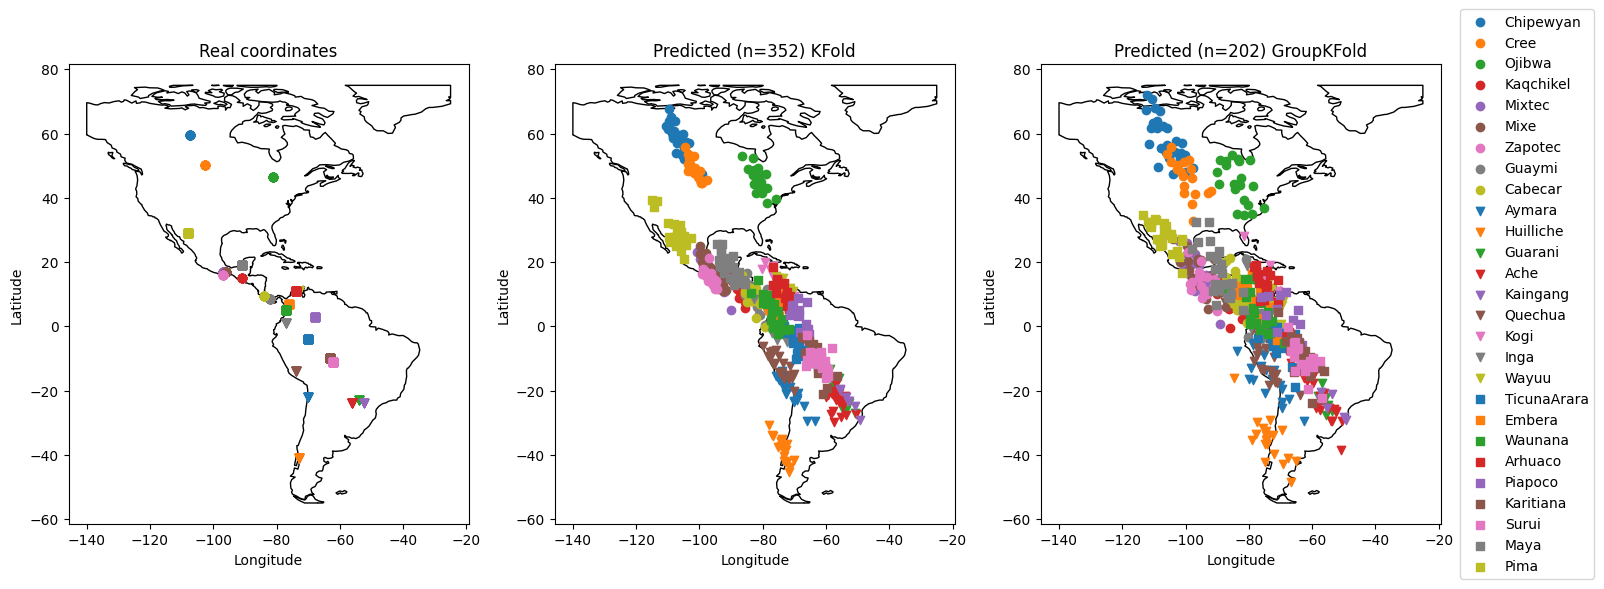

In [12]:
best_idx_kfold = np.argmin(mean_test_errors)
best_n_kfold = n_components_list[best_idx_kfold]
print(f"Best n_components for KFold: {best_n_kfold}")
print(f"Best test error for KFold:     {mean_test_errors[best_idx_kfold]:.2f} km")
print(f"Training error for KFold:      {mean_train_errors[best_idx_kfold]:.2f} km")

best_pipe = make_pipeline(PCA(n_components=best_n_kfold), LinearRegression())
best_pipe.fit(X_vals, y_both)
y_pred_best = best_pipe.predict(X_vals)
gdf_best = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(y_pred_best[:, 1], y_pred_best[:, 0]))


best_idx_group = np.argmin(mean_test_errors_group)
best_n_group = n_components_list[best_idx_group]
print(f"Best n_components for GroupKFold: {best_n_group}")
print(f"Best test error for GroupKFold:     {mean_test_errors_group[best_idx_group]:.2f} km")
print(f"Training error for GroupKFold:      {mean_train_errors_group[best_idx_group]:.2f} km")

best_pipe_group = make_pipeline(PCA(n_components=best_n_group), LinearRegression())
best_pipe_group.fit(X_vals, y_both)
y_pred_group = best_pipe_group.predict(X_vals)
gdf_group = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(y_pred_group[:, 1], y_pred_group[:, 0]))



fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, gdf_plot, title in zip(axes, [gdf, gdf_best, gdf_group], ['Real coordinates', f'Predicted (n={best_n_kfold}) KFold', f'Predicted (n={best_n_group}) GroupKFold']):
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    for i, tribe in enumerate(df['Pop'].unique()):
        mask = df['Pop'] == tribe
        ax.scatter(gdf_plot[mask].geometry.x, gdf_plot[mask].geometry.y,
                   marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')



axes[2].legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.tight_layout()
plt.show()

We choose the GroupKFold model (n=232) as our final model, with a test error of 2056 km and training error of 611 km. The KFold model (n=352, test error 1178 km) looks better, but its estimate is unreliable due to data leakage — tribe members appear in both train and test sets. The similar visual predictions of both models confirm this. An error of ~2000 km means the model predicts only the broad region, not precise locations

Let’s try the following experiment: train the model on all settlements except the last five, and then test the model on the data from those five settlements.

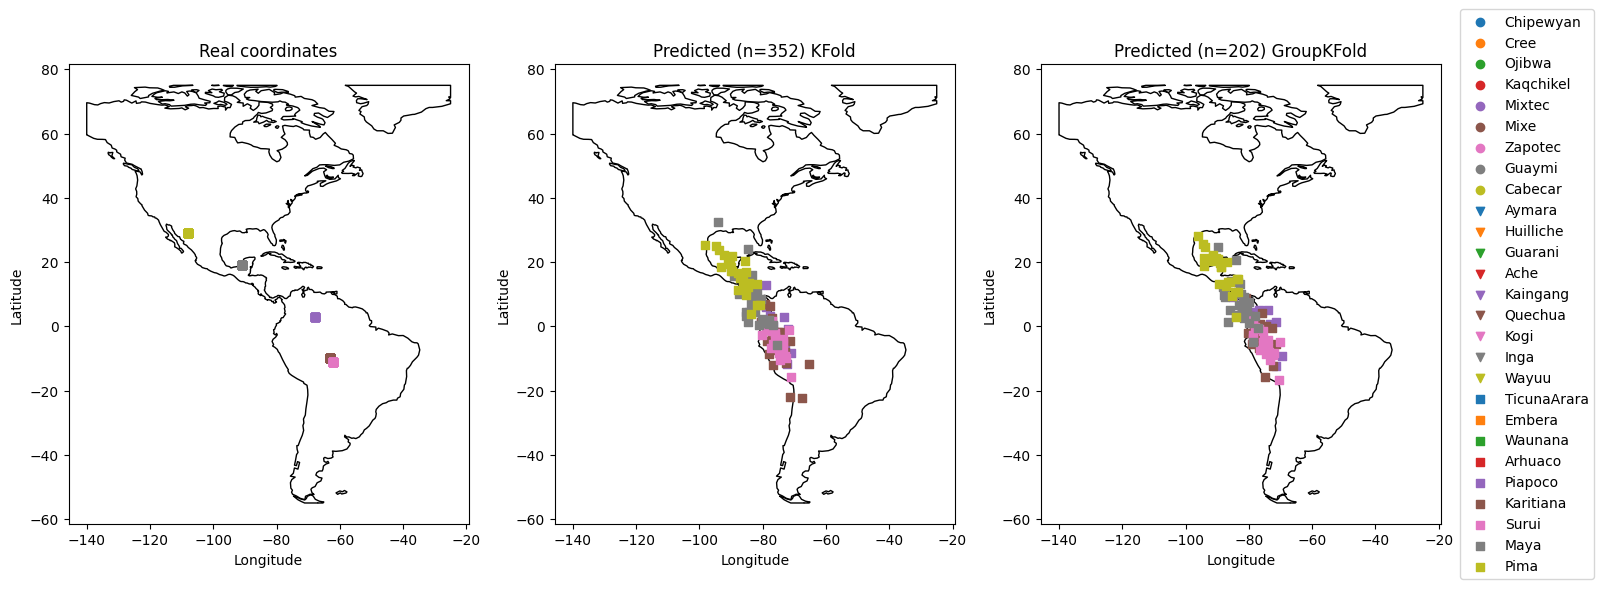

In [15]:



groups = df['Pop'].unique()

train_groups = groups[:-5]
test_groups = groups[-5:]
df_train = df[df['Pop'].isin(train_groups)]
df_test = df[df['Pop'].isin(test_groups)]
X_train = df_train[df_train.columns[8:]].values
y_train = df_train[['lat', 'long']].values
X_test = df_test[df_test.columns[8:]].values
y_test = df_test[['lat', 'long']].values

best_pipe = make_pipeline(PCA(n_components=best_n_kfold), LinearRegression())
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)
gdf_best = gpd.GeoDataFrame(df_test.copy(), geometry=gpd.points_from_xy(y_pred_best[:, 1], y_pred_best[:, 0]))


best_pipe_group = make_pipeline(PCA(n_components=best_n_group), LinearRegression())
best_pipe_group.fit(X_train, y_train)
y_pred_group = best_pipe_group.predict(X_test)
gdf_group = gpd.GeoDataFrame(df_test.copy(), geometry=gpd.points_from_xy(y_pred_group[:, 1], y_pred_group[:, 0]))


gdf_test = gpd.GeoDataFrame(df_test.copy(),geometry=gpd.points_from_xy(y_test[:,1],y_test[:,0]))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, gdf_plot, title in zip(axes, [gdf_test, gdf_best, gdf_group], ['Real coordinates', f'Predicted (n={best_n_kfold}) KFold', f'Predicted (n={best_n_group}) GroupKFold']):
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    for i, tribe in enumerate(df['Pop'].unique()):
        mask = gdf_plot['Pop'] == tribe
        ax.scatter(gdf_plot[mask].geometry.x, gdf_plot[mask].geometry.y,
                   marker=marker_list[i//9], color=colors_list[i%9], label=tribe)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')



axes[2].legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.tight_layout()
plt.show()

We can see that when the data in the training and test sets are truly independent, KFold does not yield better results, as it did previously. This confirms our theory that, in this case, GroupKFold provides a more accurate assessment of model quality.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

We conducted a study comparing the use of KFold and GroupKFold and demonstrated that, when our data exhibits dependencies, using KFold can lead to data leakage and more optimistic model estimates. Although KFold yields a lower test score, we do not observe significant differences in the graphs between these two approaches. Our final model uses GroupKFold with 232 principal components, achieving a test error of ~2056 km. This means the model can predict the broad continental region but not precise locations of individuals.

One way to improve the model is to test the hypothesis that our features depend not only on tribe but also on the country in which they are located. Another option is to use PLS instead of PCR. PLS constructs new components that take into account not only the structure of the features  X, but also their relationship with the target variable y.  If, for example, information relevant to predicting coordinates is contained in directions with low variance, PCR may discard these directions, while PLS will retain them.
